# 1. The Data Up Close: Saarland

Before analyzing nationwide patterns, let's understand the granularity of the source data. We use **Saarland** — Germany's smallest territorial state — as a representative sample. It is ideal for exploration without requiring high-performance computing.

#### Setup

First, we set up our environment and define paths to the data.

In [1]:
# ============================================================
# Setup and paths
# ============================================================
from pathlib import Path
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Define root directory (adjust if needed)
ROOT = Path.cwd().parent

# Path to Saarland partition
SAARLAND_PATH = ROOT / "data" / "raw" / "3D_building_metrics_germany_2024" / "sl_3d_building_metrics_2024.parquet"

# Filter: only buildings (function code starts with '31')
BLDG_FUNCTION_PREFIX = "31"

print(f"Saarland file exists: {SAARLAND_PATH.exists()}")

Saarland file exists: True


#### Load and Filter

Now we load the Saarland footprints and filter to buildings only. The dataset contains not only buildings but also structures like bridges, silos, and wind turbines — identified by their function codes.

In [2]:
# ============================================================
# Load Saarland footprints
# ============================================================
print("Loading Saarland footprints...")
saarland = gpd.read_parquet(SAARLAND_PATH)

print(f"Total footprints: {len(saarland):,}")
print(f"Columns: {list(saarland.columns)}")
print()

# Filter to buildings only
saarland_buildings = saarland[saarland['bldg_function'].str.startswith(BLDG_FUNCTION_PREFIX)].copy()
print(f"Buildings (function '31*'): {len(saarland_buildings):,}")
print(f"Excluded structures: {len(saarland) - len(saarland_buildings):,}")

Loading Saarland footprints...
Total footprints: 733,567
Columns: ['bldg_gmlid', 'count_bldg_parts', 'bldg_function', 'bldg_volume', 'bldg_max_measured_height', 'count_roof_surfaces', 'roof_area', 'count_wall_surfaces', 'wall_area', 'footprint_area', 'footprint_perimeter', 'geometry']

Buildings (function '31*'): 703,737
Excluded structures: 29,830


#### Basic Statistics

Let's compute summary statistics for key attributes to understand the building stock in Saarland.

In [3]:
# ============================================================
# Summary statistics
# ============================================================
summary = saarland_buildings[['bldg_volume', 'footprint_area', 'roof_area', 'bldg_max_measured_height']].describe().T

# Format for readability
summary['count'] = summary['count'].astype(int).map(lambda x: f"{x:,}")
for col in ['mean', 'std', 'min', '25%', '50%', '75%', 'max']:
    summary[col] = summary[col].map(lambda x: f"{x:,.1f}")

summary.index = ['Volume (m³)', 'Footprint (m²)', 'Roof area (m²)', 'Height (m)']
print("Summary statistics for Saarland buildings:")
display(summary)

Summary statistics for Saarland buildings:


,count,mean,std,min,25%,50%,75%,max
Volume (m³),"703,737",869.6,"8,310.0",1.0,102.0,442.6,925.7,"3,453,114.7"
Footprint (m²),"703,737",107.8,573.8,0.5,28.7,69.2,118.1,"161,507.5"
Roof area (m²),"703,737",121.2,576.8,0.5,30.6,80.2,141.9,"161,507.5"
Height (m),"703,737",7.2,3.8,0.1,3.6,6.9,10.1,131.4


> **Key Insight:** The mean is higher than the median for all metrics — a **right-skewed distribution**. Most buildings have comparable dimensions at the lower end of the scale, but a few large outliers (e.g., industrial halls, high-rise structures) are substantially larger than the average. This heterogeneity within the building stock is itself an important characteristic — it means that aggregated metrics need to be interpreted with care, as they may be strongly influenced by a small number of exceptional structures.

#### Visualize Footprints

Let's look at actual building footprints in the City of Saarlouis — a historic town with clear building patterns.

Buildings in bounding box: 58,741


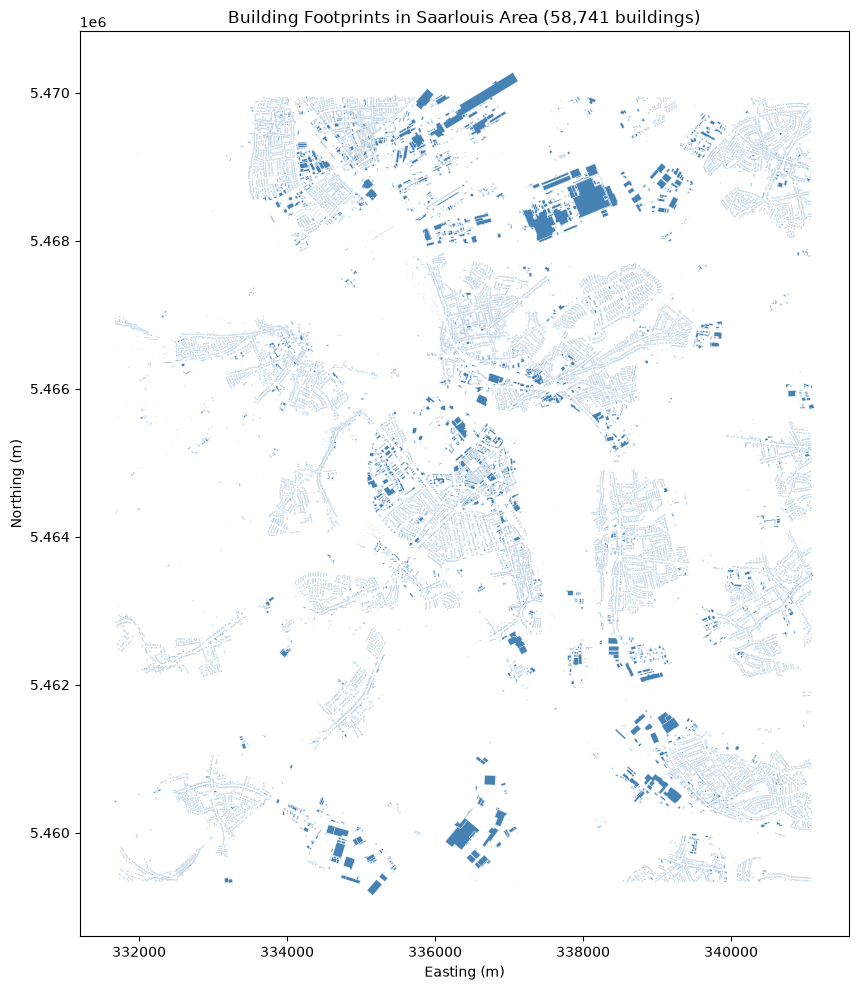

In [4]:
# ============================================================
# Plot footprints for the City of Saarlouis (by bounding box)
# ============================================================
# Define bounding box around Saarlouis
bbox = (331687.312, 5459342.458, 341076.488, 5469930.538)

# Filter footprints within the bounding box
saarlouis_buildings = saarland_buildings.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

print(f"Buildings in bounding box: {len(saarlouis_buildings):,}")

fig, ax = plt.subplots(figsize=(12, 10))

# Plot footprints
saarlouis_buildings.plot(ax=ax, color='steelblue', edgecolor='white', linewidth=0.2)

ax.set_title(f"Building Footprints in Saarlouis Area ({len(saarlouis_buildings):,} buildings)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

#### From Local Detail to Germany-Wide Patterns

We've now seen what the data looks like at the building level. But our goal is to understand **Germany-wide patterns**.

To do this, we need to:
1. **Aggregate** individual footprints to administrative units
2. **Combine** with spatial classifications (RegioStaR)
3. **Analyze** the distribution of building stock across all regions

This is exactly what we'll do in {doc}`2. Analyzing Building Stock Patterns <203b_analysis>`.